In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import datasets
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0



In [8]:
base_model = ResNet50(weights='imagenet',
                      include_top=False
                      )

In [9]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=x)

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_frozen = model.fit(x_train, y_train,
                           epochs=5,
                           validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 16ms/step - accuracy: 0.2380 - loss: 2.0734 - val_accuracy: 0.2998 - val_loss: 1.9224
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3132 - loss: 1.8861 - val_accuracy: 0.3205 - val_loss: 1.8807
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3392 - loss: 1.8247 - val_accuracy: 0.3565 - val_loss: 1.8025
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3542 - loss: 1.7933 - val_accuracy: 0.3678 - val_loss: 1.7707
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3620 - loss: 1.7670 - val_accuracy: 0.3716 - val_loss: 1.7382


In [12]:
# Unfreeze last few layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Recompile with lower learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_finetune = model.fit(x_train, y_train,
                             epochs=5,
                             validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 20ms/step - accuracy: 0.2253 - loss: 3.0393 - val_accuracy: 0.2962 - val_loss: 2.1843
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.2897 - loss: 2.0377 - val_accuracy: 0.3269 - val_loss: 1.9797
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.3278 - loss: 1.8985 - val_accuracy: 0.3508 - val_loss: 1.8851
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3475 - loss: 1.8200 - val_accuracy: 0.3680 - val_loss: 1.8134
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.3721 - loss: 1.7596 - val_accuracy: 0.3764 - val_loss: 1.7843


In [13]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Final Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3764 - loss: 1.7843
Final Accuracy: 0.3763999938964844


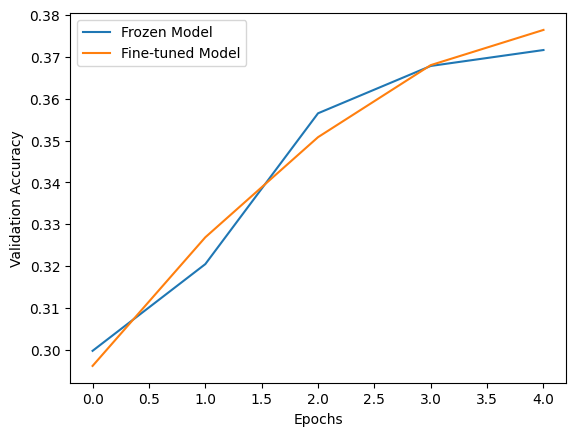

In [14]:
# Frozen vs Fine-tuned Accuracy
plt.plot(history_frozen.history['val_accuracy'], label='Frozen Model')
plt.plot(history_finetune.history['val_accuracy'], label='Fine-tuned Model')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()